<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/NLP-2026/Lecture_2/Transformers_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformer: полная теория

## Введение: почему Transformer стал революцией

### Исторический контекст и предпосылки

В 2017 году команда Google Brain опубликовала статью «Attention Is All You Need», которая представила архитектуру Transformer. Это событие стало поворотным моментом в истории NLP. Чтобы понять, почему это произошло, нужно вспомнить, с какими проблемами сталкивались исследователи до этого.

До 2017 года доминировали рекуррентные сети: RNN, LSTM, GRU. Они показали хорошие результаты в машинном переводе, распознавании речи, языковом моделировании. Но у них были фундаментальные ограничения, которые становились всё более болезненными по мере роста объёмов данных и сложности задач.

**Первая проблема — последовательная обработка.** RNN обрабатывает последовательность по одному элементу за раз. На каждом шаге $t$ скрытое состояние $h_t$ зависит от предыдущего состояния $h_{t-1}$. Это означает, что нельзя вычислить $h_t$, не вычислив $h_{t-1}$, а $h_{t-1}$ — не вычислив $h_{t-2}$, и так далее. Вся последовательность обрабатывается последовательно. Для последовательности из 1000 токенов нужно 1000 последовательных шагов. На GPU, где параллелизм — ключ к производительности, это означает, что большая часть вычислительных ресурсов простаивает. Обучение занимает дни и недели вместо часов.

**Вторая проблема — затухающие градиенты.** При обучении RNN используется backpropagation through time: градиент функции потерь распространяется назад по времени. Градиент по начальному состоянию $h_0$ равен произведению $T$ матриц Якоби. Если спектральный радиус каждой матрицы меньше 1, произведение экспоненциально затухает. Если больше 1 — экспоненциально взрывается. LSTM смягчает проблему через cell state, но не решает её полностью. Это означает, что RNN не может эффективно обучаться на длинных последовательностях: информация о далёких словах теряется.

**Третья проблема — бутылочное горлышко фиксированного вектора.** В encoder-decoder архитектурах encoder сжимает всю входную последовательность в один вектор фиксированной размерности. Decoder использует этот вектор для генерации перевода. Проблема в том, что один вектор не может вместить всю информацию о длинном предложении. Для коротких предложений это работает, для длинных — информация теряется. Это называется бутылочным горлышком. Качество перевода резко падает для предложений длиннее 20–30 слов.

**Четвёртая проблема — отсутствие интерпретируемости.** RNN не даёт явного ответа на вопрос: «Какие слова входной последовательности повлияли на текущее решение?» Мы можем анализировать градиенты или ворота, но это косвенные методы. Нет явного механизма, который бы показывал, на что «смотрит» модель.

Attention, как мы разобрали в предыдущей лекции, решает эти проблемы. Он позволяет:

- **Параллелизовать вычисления** по длине последовательности;
- **Улавливать долгосрочные зависимости** без затухания;
- **Создавать динамическое представление** вместо фиксированного вектора;
- **Давать интерпретируемые веса** attention.

Но сам по себе attention — это лишь механизм. Transformer — это **архитектура**, которая строится исключительно на attention, без рекуррентности и свёрток. Название статьи — «Attention Is All You Need» — не преувеличение. Transformer показал, что для обработки последовательностей достаточно только attention и полносвязных слоёв.

### Что дал Transformer

Transformer позволил:

1. **Обучать очень глубокие модели.** BERT — 12–24 слоя, GPT-3 — 96 слоёв. Без residual connections и layer normalization это было бы невозможно.
2. **Параллелизовать вычисления.** Обучение на миллиардах слов стало возможным за разумное время.
3. **Достичь state-of-the-art** на широком спектре задач: машинный перевод, языковое моделирование, question answering, суммаризация, классификация.
4. **Заложить основу** для BERT, GPT, T5, ViT и всех современных моделей.

Transformer состоит из двух основных компонентов: **encoder** и **decoder**. Каждый из них — это стек из $N$ идентичных слоёв. Encoder обрабатывает входную последовательность, decoder генерирует выходную.

---

## 1. Общая архитектура

### 1.1 Высокоуровневая схема и её смысл

Transformer имеет архитектуру encoder-decoder:

```
Входная последовательность
        ↓
[Embedding + Positional Encoding]
        ↓
[Encoder Layer 1]
        ↓
[Encoder Layer 2]
        ↓
...
        ↓
[Encoder Layer N]
        ↓
        └──────────────┐
                       ↓
                [Cross-Attention]
                       ↑
        ┌──────────────┘
        ↓
[Embedding + Positional Encoding]
        ↓
[Decoder Layer 1]
        ↓
[Decoder Layer 2]
        ↓
...
        ↓
[Decoder Layer N]
        ↓
[Linear + Softmax]
        ↓
Выходная последовательность
```


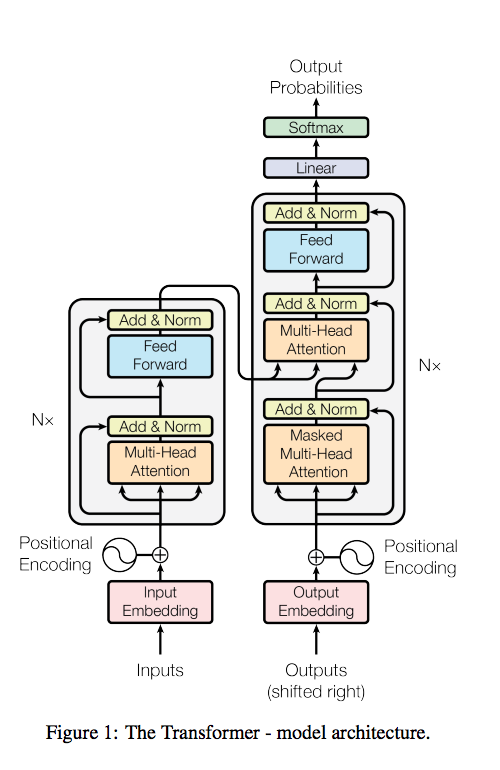


**Разберём схему по шагам, объясняя, зачем нужен каждый компонент.**

1. **Входная последовательность** токенов подаётся на вход. Это может быть предложение на исходном языке (для перевода), вопрос (для QA), текст (для классификации).

2. **Embedding layer** преобразует каждый токен в вектор размерности $d_{\text{model}}$. Это нужно, потому что нейросети работают с числами, а не с токенами. Embedding layer обучается вместе с моделью. Например, токен «кошка» может получить вектор $(0.2, -0.1, 0.5, \ldots)$.

3. **Positional encoding** добавляет информацию о позиции каждого токена. Это критически важно, потому что self-attention не различает порядок слов. Без positional encoding предложения «кошка сидит на окне» и «окне на сидит кошка» дали бы одинаковый результат.

4. **Encoder** состоит из $N$ идентичных слоёв. Каждый слой обрабатывает последовательность, используя self-attention и feed-forward. Задача encoder — создать **контекстуализированное представление** каждого токена, учитывая весь контекст.

5. **Выход encoder** — это последовательность векторов $Z \in \mathbb{R}^{n \times d_{\text{model}}}$, где $n$ — длина входной последовательности. Каждый вектор содержит информацию о токене и его контексте.

6. **Decoder** состоит из $N$ идентичных слоёв. Каждый слой использует masked self-attention (чтобы не подглядывать в будущее), cross-attention (чтобы смотреть на encoder) и feed-forward. Задача decoder — генерировать выходную последовательность.

7. **Финальный линейный слой** проецирует выход decoder в пространство словаря. Если словарь содержит $|V|$ слов, то линейный слой имеет размер $d_{\text{model}} \times |V|$.

8. **Softmax** превращает логиты в вероятности. Для каждого токена мы получаем распределение по словарю.

### 1.2 Компоненты и их назначение

**Encoder** состоит из $N$ идентичных слоёв. Каждый слой имеет два подкомпонента:

1. **Multi-Head Self-Attention** — каждое слово «видит» все остальные слова входной последовательности. Это позволяет модели улавливать связи между словами, независимо от расстояния между ними. Например, при обработке слова «bank» в предложении «I went to the bank to deposit money» модель может обратить внимание на «money» (финансовый контекст). В предложении «The river bank was flooded» — на «river» (речной контекст).

2. **Feed-Forward Network** — применяется к каждому слову независимо. Это добавляет нелинейность и увеличивает ёмкость модели. Без FFN трансформер был бы просто последовательностью линейных attention-слоёв.

**Decoder** состоит из $N$ идентичных слоёв. Каждый слой имеет три подкомпонента:

1. **Masked Multi-Head Self-Attention** — каждое слово «видит» только себя и предыдущие слова. Это нужно, потому что decoder генерирует текст авторегрессионно: при предсказании слова $t$ он не должен видеть слова $t+1, t+2, \ldots$.

2. **Multi-Head Cross-Attention** — запросы из decoder, ключи и значения из encoder. Это позволяет decoder «смотреть» на входную последовательность при генерации каждого слова. Без cross-attention decoder не имел бы доступа к входу.

3. **Feed-Forward Network** — то же самое, что в encoder.

**Вокруг каждого подкомпонента** применяются:

- **Residual connection** — добавление входа к выходу подкомпонента. Это решает проблему затухающих градиентов и позволяет обучать очень глубокие модели.
- **Layer normalization** — нормализация активаций. Это стабилизирует обучение и ускоряет сходимость.

### 1.3 Формула слоя и её смысл

Каждый подкомпонент оборачивается в:

$$
\text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x)),
$$

где $\text{Sublayer}$ — это либо attention, либо feed-forward network.

**Разберём формулу по шагам, объясняя, зачем нужен каждый элемент:**

1. **Вход $x$** подаётся в подкомпонент $\text{Sublayer}$. Это может быть вектор слова, последовательность векторов, или выход предыдущего слоя.

2. **Выход подкомпонента** $\text{Sublayer}(x)$ вычисляется. Это может быть multi-head attention, feed-forward network или cross-attention. Подкомпонент преобразует вход в новое представление.

3. **Residual connection:** $x + \text{Sublayer}(x)$ — вход добавляется к выходу. Зачем это нужно? Без residual connection градиент при backpropagation должен пройти через все слои, и он может затухнуть. С residual connection градиент может «протекать» напрямую через identity-путь, минуя sublayer. Это позволяет обучать очень глубокие модели (96 слоёв в GPT-3).

4. **Layer normalization:** результат нормализуется. Зачем? Нормализация стабилизирует распределение активаций, что ускоряет сходимость и предотвращает взрыв/затухание градиентов.

**Тонкий момент:** в оригинальной статье используется **post-layer normalization**: layer norm применяется **после** residual connection. В более поздних моделях (например, GPT-2) используется **pre-layer normalization**: layer norm применяется **до** sublayer.

**Post-LN (оригинальный Transformer):**

$$
\text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x)).
$$

**Pre-LN (современные модели):**

$$
\text{Output} = x + \text{Sublayer}(\text{LayerNorm}(x)).
$$

**Почему pre-LN лучше:** при обучении глубоких моделей (24+ слоя) pre-LN более стабильна. В post-LN градиент проходит через layer norm, что может вызывать нестабильность. В pre-LN нормализация происходит до sublayer, и residual connection добавляется после, что позволяет градиенту течь напрямую через всю сеть без нормализации. Это особенно важно для моделей с сотнями слоёв.

---

## 2. Encoder

### 2.1 Общая структура и её смысл

Encoder состоит из $N$ идентичных слоёв. Каждый слой:

1. **Multi-Head Self-Attention:** каждое слово «видит» все остальные слова входной последовательности.
2. **Feed-Forward Network:** применяется к каждому слову независимо.

**Вход encoder:** последовательность эмбеддингов $X \in \mathbb{R}^{n \times d_{\text{model}}}$, где $n$ — длина последовательности, $d_{\text{model}}$ — размерность модели.

**Выход encoder:** последовательность $Z \in \mathbb{R}^{n \times d_{\text{model}}}$.

**Зачем нужен encoder:** encoder создаёт **контекстуализированное представление** каждого токена. В отличие от статических эмбеддингов (Word2Vec, GloVe), где каждое слово имеет один фиксированный вектор, encoder учитывает контекст. Слово «bank» в разных предложениях получит разные векторы.

**Тонкий момент:** размерность входа и выхода encoder **одинакова** ($d_{\text{model}}$). Это позволяет складывать слои в стек: выход одного слоя становится входом следующего.

### 2.2 Multi-Head Self-Attention: зачем и как

**Зачем нужен self-attention:** каждое слово должно иметь возможность «посмотреть» на все остальные слова и решить, какие из них важны для его понимания. Например, при обработке местоимения «it» в предложении «The animal didn't cross the street because it was too tired» модель должна понять, что «it» относится к «animal», а не к «street». Self-attention позволяет это сделать.

**Формально:**

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O,
$$

где:

$$
\text{head}_i = \text{Attention}(Q W_i^Q, K W_i^K, V W_i^V),
$$

$$
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{Q K^\top}{\sqrt{d_k}} \right) V.
$$

**В self-attention encoder:**

$$
Q = X W^Q, \quad K = X W^K, \quad V = X W^V,
$$

где $X$ — вход слоя.

**Разберём каждую формулу и объясним, что она даёт:**

**Формула $Q = X W^Q$, $K = X W^K$, $V = X W^V$:**

- $X$ — это входная последовательность, матрица $n \times d_{\text{model}}$. Каждая строка — вектор одного токена.
- $W^Q, W^K, W^V$ — обучаемые матрицы размера $d_{\text{model}} \times d_{\text{model}}$. Они проецируют вход в пространства запросов, ключей и значений.
- $Q, K, V$ — результат проекции, матрицы $n \times d_{\text{model}}$.

**Зачем нужны три разные проекции:** если бы мы использовали $Q = K = V = X$, то attention вычислял бы сходство каждого слова с самим собой. Но нам нужно, чтобы каждое слово могло «спросить» (Query) о других словах (Key) и получить их содержимое (Value). Разные проекции позволяют модели разделить эти роли.

**Формула $\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{Q K^\top}{\sqrt{d_k}} \right) V$:**

- $Q K^\top$ — матрица сходств размера $n \times n$. Элемент $(i, j)$ — скалярное произведение $i$-го запроса и $j$-го ключа. Чем больше произведение, тем более релевантно $j$-е слово для $i$-го.
- $\sqrt{d_k}$ — масштабирующий множитель. Без него значения $Q K^\top$ могут быть большими, softmax становится «жёстким», градиенты затухают.
- $\text{softmax}$ — нормализует сходства в вероятности. Для каждого запроса $i$ веса суммируются в 1.
- Умножение на $V$ — взвешенная сумма значений. Для каждого запроса $i$ мы получаем смесь значений всех слов, где веса — это attention-веса.

**Формула $\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O$:**

- Мы вычисляем $h$ attention-голов параллельно. Каждая голова использует свои проекции $W_i^Q, W_i^K, W_i^V$.
- Результаты конкатенируются и проецируются через $W^O$.
- Зачем несколько голов: каждая голова может специализироваться на разных аспектах. Одна — на синтаксисе, другая — на семантике, третья — на позициях.

**Тонкий момент:** в encoder **нет маскирования**. Все слова видны одновременно. Это позволяет каждому слову «видеть» весь контекст. В отличие от decoder, где используется causal mask, encoder обрабатывает всю последовательность целиком.

### 2.3 Детальный разбор Multi-Head Attention с объяснениями

**Шаг 1: проекции для каждой головы.**

Для головы $i$:

$$
Q_i = X W_i^Q \in \mathbb{R}^{n \times d_k},
$$

$$
K_i = X W_i^K \in \mathbb{R}^{n \times d_k},
$$

$$
V_i = X W_i^V \in \mathbb{R}^{n \times d_v}.
$$

**Разберём умножение матриц:**

$X$ имеет размер $n \times d_{\text{model}}$, $W_i^Q$ имеет размер $d_{\text{model}} \times d_k$. Их произведение:

$$
(X W_i^Q)_{jl} = \sum_{m=1}^{d_{\text{model}}} X_{jm} (W_i^Q)_{ml}.
$$

Это означает, что каждая строка $X$ (вектор слова) проецируется в $d_k$-мерное пространство через матрицу $W_i^Q$. Другими словами, мы «сжимаем» $d_{\text{model}}$-мерный вектор в $d_k$-мерный, но делаем это **по-разному** для каждой головы.

**Почему разные проекции для разных голов:** каждая голова должна уметь фокусироваться на своём аспекте. Например, одна голова может улавливать синтаксические связи, другая — семантические, третья — позиционные. Разные проекции позволяют головам «смотреть» на разные подпространства входа. Если бы все головы использовали одни и те же проекции, они были бы идентичны, и multi-head не давал бы преимущества.

**Шаг 2: scaled dot-product attention для каждой головы.**

$$
\text{head}_i = \text{softmax}\left( \frac{Q_i K_i^\top}{\sqrt{d_k}} \right) V_i.
$$

**Разберём по шагам:**

**Шаг 2.1: вычисление $Q_i K_i^\top$.**

$$
(Q_i K_i^\top)_{jl} = \sum_{m=1}^{d_k} (Q_i)_{jm} (K_i)_{lm}.
$$

Это матрица размера $n \times n$, где элемент $(j, l)$ — скалярное произведение $j$-го запроса и $l$-го ключа.

**Покомпонентно:** $(Q_i)_{jm}$ — $m$-я компонента $j$-го запроса. $(K_i)_{lm}$ — $m$-я компонента $l$-го ключа. Их произведение суммируется по $m$.

**Что это даёт:** мы получаем матрицу сходств между всеми парами слов. Элемент $(j, l)$ показывает, насколько $j$-е слово «заинтересовано» в $l$-м слове.

**Шаг 2.2: масштабирование.**

$$
\frac{(Q_i K_i^\top)_{jl}}{\sqrt{d_k}}.
$$

**Зачем масштабировать:** без масштабирования значения $q \cdot k$ могут быть большими. Пусть $q$ и $k$ — случайные векторы с компонентами, независимо распределёнными с нулевым средним и единичной дисперсией. Тогда дисперсия $q^\top k$ равна $d_k$, а стандартное отклонение — $\sqrt{d_k}$. При $d_k = 512$ стандартное отклонение $\approx 22.6$. Значения скалярных произведений могут быть в диапазоне $[-70, 70]$. Softmax от таких значений становится «жёстким»: одно значение доминирует, остальные близки к нулю. Градиенты через softmax затухают, обучение замедляется.

**Решение:** деление на $\sqrt{d_k}$ делает дисперсию равной 1, стандартное отклонение — 1. Softmax становится более «мягким», градиенты не затухают.

**Шаг 2.3: softmax по строкам.**

$$
\alpha_{jl} = \frac{\exp\left( \frac{(Q_i K_i^\top)_{jl}}{\sqrt{d_k}} \right)}{\sum_{l'=1}^{n} \exp\left( \frac{(Q_i K_i^\top)_{jl'}}{\sqrt{d_k}} \right)}.
$$

Это attention-веса. Для каждого запроса $j$ веса суммируются в 1 по всем ключам $l$.

**Свойства:** $\alpha_{jl} \in [0, 1]$, $\sum_l \alpha_{jl} = 1$. Это распределение вероятностей. Чем больше $\alpha_{jl}$, тем больше внимания $j$-е слово уделяет $l$-му.

**Шаг 2.4: взвешенная сумма значений.**

$$
(\text{head}_i)_{jm} = \sum_{l=1}^{n} \alpha_{jl} (V_i)_{lm}.
$$

Для каждого запроса $j$ мы вычисляем взвешенную сумму значений всех ключей. Веса — это attention-веса.

**Что это даёт:** мы получаем новое представление $j$-го слова, которое является смесью значений всех слов, где веса определяются релевантностью. Если $j$-е слово сильно связано с $l$-м, то $l$-е слово внесёт большой вклад в новое представление $j$-го.

**Шаг 3: конкатенация голов.**

$$
\text{Concat}(\text{head}_1, \ldots, \text{head}_h) \in \mathbb{R}^{n \times h d_v}.
$$

Результаты всех голов конкатенируются по последней оси. Если $d_v = d_{\text{model}} / h$, то $h d_v = d_{\text{model}}$.

**Зачем конкатенировать:** каждая голова уловила свой аспект. Конкатенация объединяет эти аспекты в одно представление.

**Шаг 4: проекция выхода.**

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O \in \mathbb{R}^{n \times d_{\text{model}}}.
$$

$W^O \in \mathbb{R}^{h d_v \times d_{\text{model}}}$ — обучаемая матрица, которая смешивает информацию от разных голов.

**Тонкий момент:** $W^O$ — это не просто «сжатие» размерности. Это **обучаемое** преобразование, которое позволяет модели комбинировать информацию от разных голов оптимальным образом. Без $W^O$ мы бы просто конкатенировали головы, но не могли бы их смешивать.

### 2.4 Feed-Forward Network: зачем и как

После attention применяется **position-wise feed-forward network**. Он применяется к каждой позиции **независимо**:

$$
\text{FFN}(x) = \max(0, x W_1 + b_1) W_2 + b_2,
$$

где:

- $W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{ff}}$;
- $W_2 \in \mathbb{R}^{d_{ff} \times d_{\text{model}}}$;
- $b_1 \in \mathbb{R}^{d_{ff}}$;
- $b_2 \in \mathbb{R}^{d_{\text{model}}}$.

**Зачем нужен FFN:** attention — это линейная операция (взвешенная сумма). Без нелинейности вся модель была бы линейной, что ограничило бы её выразительность. FFN добавляет нелинейность (ReLU) и увеличивает ёмкость модели. FFN содержит примерно $\frac{2}{3}$ всех параметров трансформера, поэтому он критически важен.

**Разберём формулу по шагам:**

**Шаг 1: линейное преобразование.**

$$
z_1 = x W_1 + b_1 \in \mathbb{R}^{d_{ff}}.
$$

Это проекция из $d_{\text{model}}$ в $d_{ff}$ (обычно $d_{ff} = 4 d_{\text{model}}$).

**Покомпонентно:**

$$
(z_1)_k = \sum_{j=1}^{d_{\text{model}}} x_j (W_1)_{jk} + (b_1)_k, \quad k = 1, \ldots, d_{ff}.
$$

**Интерпретация:** мы умножаем вектор $x$ на матрицу $W_1$, получая вектор размерности $d_{ff}$. Это «расширение» размерности. Зачем расширять: это увеличивает ёмкость модели. Большая размерность позволяет модели улавливать более сложные зависимости.

**Шаг 2: нелинейность.**

$$
z_2 = \max(0, z_1) \in \mathbb{R}^{d_{ff}}.
$$

ReLU применяется поэлементно:

$$
(z_2)_k = \max(0, (z_1)_k).
$$

**Зачем нелинейность:** без нелинейности FFN был бы просто линейным преобразованием, и вся модель была бы линейной. ReLU добавляет нелинейность, что позволяет модели улавливать сложные зависимости. ReLU также эффективен вычислительно и не имеет проблемы затухающих градиентов для положительных значений.

**Шаг 3: линейное преобразование.**

$$
\text{FFN}(x) = z_2 W_2 + b_2 \in \mathbb{R}^{d_{\text{model}}}.
$$

**Покомпонентно:**

$$
(\text{FFN}(x))_j = \sum_{k=1}^{d_{ff}} (z_2)_k (W_2)_{kj} + (b_2)_j, \quad j = 1, \ldots, d_{\text{model}}.
$$

**Интерпретация:** мы «сжимаем» вектор обратно из $d_{ff}$ в $d_{\text{model}}$. Это нужно, чтобы выход FFN имел ту же размерность, что и вход, и мог быть сложен с residual connection.

**Тонкий момент:** FFN одинаков для всех позиций (position-wise), но **разные** FFN в разных слоях. То есть параметры $W_1, W_2$ разные для каждого слоя. Это позволяет каждому слою учить свои преобразования.

**Почему $d_{ff} = 4 d_{\text{model}}$:** это эмпирическая рекомендация из оригинальной статьи. Она хорошо работает на практике. FFN содержит примерно $\frac{2}{3}$ всех параметров трансформера, поэтому увеличение $d_{ff}$ значительно увеличивает ёмкость модели. В некоторых моделях используется $d_{ff} = \frac{8}{3} d_{\text{model}}$ (например, в Llama).

### 2.5 Полный слой encoder: как всё собирается

**Формально:**

$$
Z = \text{LayerNorm}(X + \text{MultiHead}(X, X, X)),
$$

$$
\text{Output} = \text{LayerNorm}(Z + \text{FFN}(Z)).
$$

**Разберём по шагам, объясняя, что происходит:**

**Шаг 1: self-attention.**

$$
A = \text{MultiHead}(X, X, X).
$$

Каждое слово «смотрит» на все остальные слова и создаёт новое представление, которое является смесью значений всех слов. Это представление учитывает контекст.

**Шаг 2: residual + layer norm.**

$$
Z = \text{LayerNorm}(X + A).
$$

Мы добавляем исходный вход $X$ к выходу attention $A$. Это residual connection: если attention не дал полезного преобразования, информация всё равно сохранится через $X$. Затем нормализуем.

**Шаг 3: feed-forward.**

$$
F = \text{FFN}(Z).
$$

Применяем FFN к каждому слову независимо. Это добавляет нелинейность и увеличивает ёмкость.

**Шаг 4: residual + layer norm.**

$$
\text{Output} = \text{LayerNorm}(Z + F).
$$

Снова residual connection и нормализация.

**Тонкий момент:** в pre-LN версии порядок другой:

$$
Z = X + \text{MultiHead}(\text{LayerNorm}(X), \text{LayerNorm}(X), \text{LayerNorm}(X)),
$$

$$
\text{Output} = Z + \text{FFN}(\text{LayerNorm}(Z)).
$$

**Разница:** в post-LN нормализация применяется после residual. В pre-LN — до sublayer. Pre-LN более стабильна для глубоких моделей.

---

## 3. Decoder

### 3.1 Общая структура и её смысл

Decoder состоит из $N$ идентичных слоёв. Каждый слой:

1. **Masked Multi-Head Self-Attention:** каждое слово «видит» только себя и предыдущие слова.
2. **Multi-Head Cross-Attention:** запросы из decoder, ключи и значения из encoder.
3. **Feed-Forward Network.**

**Вход decoder:** последовательность эмбеддингов $Y \in \mathbb{R}^{m \times d_{\text{model}}}$, где $m$ — длина выходной последовательности.

**Выход decoder:** последовательность $\in \mathbb{R}^{m \times d_{\text{model}}}$.

**Зачем нужен decoder:** decoder генерирует выходную последовательность. В машинном переводе — это перевод. В суммаризации — это краткое содержание. В question answering — это ответ.

**Тонкий момент:** decoder работает авторегрессионно. На каждом шаге он предсказывает следующее слово, используя только предыдущие. Это достигается через causal mask.

### 3.2 Masked Multi-Head Self-Attention: зачем маскировать

Это то же самое, что self-attention в encoder, но с **causal mask**:

$$
M_{ij} = \begin{cases} 0, & \text{если } j \le i, \\ -\infty, & \text{если } j > i. \end{cases}
$$

$$
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{Q K^\top}{\sqrt{d_k}} + M \right) V.
$$

**Зачем маскировать:** при генерации текста модель не должна видеть будущие слова. Она должна предсказывать следующее слово, используя только предыдущие. Без маскирования модель «подглядывала» бы в будущее, что привело бы к переобучению: на обучении она видела бы правильный ответ, а на inference — нет.

**Разберём по шагам:**

**Шаг 1: вычисление $Q K^\top$.**

$$
(Q K^\top)_{ij} = \sum_{l=1}^{d_k} Q_{il} K_{jl}.
$$

**Шаг 2: добавление маски.**

$$
(Q K^\top)_{ij} + M_{ij}.
$$

Для $j > i$: $M_{ij} = -\infty$, поэтому $(Q K^\top)_{ij} + (-\infty) = -\infty$.

**Шаг 3: масштабирование и softmax.**

$$
\alpha_{ij} = \frac{\exp\left( \frac{(Q K^\top)_{ij}}{\sqrt{d_k}} + M_{ij} \right)}{\sum_{j'=1}^{n} \exp\left( \frac{(Q K^\top)_{ij'}}{\sqrt{d_k}} + M_{ij'} \right)}.
$$

Для $j > i$: $\exp(-\infty) = 0$, поэтому $\alpha_{ij} = 0$.

**Шаг 4: взвешенная сумма.**

$$
\text{out}_i = \sum_{j=1}^{n} \alpha_{ij} V_j = \sum_{j \le i} \alpha_{ij} V_j.
$$

**Интерпретация:** каждое слово $i$ обращает внимание только на себя и предыдущие слова. Будущие слова не влияют на текущее.

**Пример:** при генерации слова «сидит» в предложении «кошка сидит на окне» decoder видит только «кошка» и «сидит». Он не видит «на» и «окне», потому что они ещё не сгенерированы.

### 3.3 Multi-Head Cross-Attention: зачем и как

Cross-attention связывает decoder с encoder:

$$
Q = Y_{\text{dec}} W^Q, \quad K = Z_{\text{enc}} W^K, \quad V = Z_{\text{enc}} W^V,
$$

где:

- $Y_{\text{dec}}$ — выход предыдущего слоя decoder;
- $Z_{\text{enc}}$ — выход encoder.

$$
\text{CrossAttention}(Y_{\text{dec}}, Z_{\text{enc}}) = \text{softmax}\left( \frac{Q K^\top}{\sqrt{d_k}} \right) V.
$$

**Зачем нужен cross-attention:** decoder должен «смотреть» на входную последовательность при генерации каждого слова. Без cross-attention decoder не имел бы доступа к входу и не мог бы переводить. Cross-attention позволяет decoder «спросить» encoder: «Какие части входа важны для генерации текущего слова?»

**Интерпретация:** каждый запрос из decoder сравнивается со всеми ключами encoder. Веса attention показывают, какие части исходного предложения важны для генерации текущего слова.

**Размерности:**

- $Y_{\text{dec}} \in \mathbb{R}^{m \times d_{\text{model}}}$;
- $Z_{\text{enc}} \in \mathbb{R}^{n \times d_{\text{model}}}$;
- $Q \in \mathbb{R}^{m \times d_k}$;
- $K, V \in \mathbb{R}^{n \times d_k}$;
- $Q K^\top \in \mathbb{R}^{m \times n}$;
- output $\in \mathbb{R}^{m \times d_v}$.

**Тонкий момент:** $m$ и $n$ могут различаться. В машинном переводе длина перевода может отличаться от длины исходного предложения. Cross-attention позволяет это.

**Пример:** при переводе немецкого предложения на английский, encoder обрабатывает немецкое предложение, decoder генерирует английское. Cross-attention позволяет decoder «смотреть» на немецкое предложение при генерации каждого английского слова.

### 3.4 Feed-Forward Network

То же самое, что в encoder:

$$
\text{FFN}(x) = \max(0, x W_1 + b_1) W_2 + b_2.
$$

### 3.5 Полный слой decoder: как всё собирается

**Формально:**

**Шаг 1: masked self-attention.**

$$
A_1 = \text{MaskedMultiHead}(Y, Y, Y).
$$

Decoder обрабатывает свои предыдущие слова, используя masked self-attention.

**Шаг 2: residual + layer norm.**

$$
Z_1 = \text{LayerNorm}(Y + A_1).
$$

**Шаг 3: cross-attention.**

$$
A_2 = \text{CrossAttention}(Z_1, Z_{\text{enc}}, Z_{\text{enc}}).
$$

Decoder «смотрит» на encoder.

**Шаг 4: residual + layer norm.**

$$
Z_2 = \text{LayerNorm}(Z_1 + A_2).
$$

**Шаг 5: feed-forward.**

$$
F = \text{FFN}(Z_2).
$$

**Шаг 6: residual + layer norm.**

$$
\text{Output} = \text{LayerNorm}(Z_2 + F).
$$

**Тонкий момент:** cross-attention идёт **после** masked self-attention и **перед** feed-forward. Это позволяет decoder сначала обработать свои предыдущие слова, затем «посмотреть» на encoder, и только потом принять решение.

---

## 4. Positional Encoding

### 4.1 Проблема: attention не знает порядка

Self-attention **инвариантен к перестановке**. Если переставить слова, результат attention переставится, но не изменится содержательно. Это означает, что attention не различает порядок слов.

**Математически:** пусть $P$ — матрица перестановки. Тогда:

$$
\text{SelfAttention}(P X) = P \cdot \text{SelfAttention}(X).
$$

**Доказательство:**

$$
Q' = P X W^Q = P Q, \quad K' = P X W^K = P K, \quad V' = P X W^V = P V.
$$

$$
Q' K'^\top = P Q (P K)^\top = P Q K^\top P^\top.
$$

Поскольку $P$ — перестановка, $P^\top P = I$. Softmax применяется поэлементно:

$$
\text{softmax}(Q' K'^\top / \sqrt{d_k}) = P \cdot \text{softmax}(Q K^\top / \sqrt{d_k}) \cdot P^\top.
$$

Умножаем на $V'$:

$$
\text{output}' = P \cdot \text{softmax}(Q K^\top / \sqrt{d_k}) \cdot P^\top \cdot P V = P \cdot \text{softmax}(Q K^\top / \sqrt{d_k}) V = P \cdot \text{output}.
$$

**Следствие:** self-attention не различает порядок слов. Предложения «кошка сидит на окне» и «окне на сидит кошка» дали бы одинаковый результат (с точностью до перестановки). Но это разные предложения! Нужно добавить информацию о позиции.

### 4.2 Формула синусоидального positional encoding

$$
p_{i, 2k} = \sin\left( \frac{i}{10000^{2k / d_{\text{model}}}} \right),
$$

$$
p_{i, 2k+1} = \cos\left( \frac{i}{10000^{2k / d_{\text{model}}}} \right),
$$

где:

- $i$ — позиция в последовательности ($i = 0, 1, 2, \ldots$);
- $k$ — индекс размерности ($k = 0, 1, \ldots, d_{\text{model}}/2 - 1$);
- $d_{\text{model}}$ — размерность эмбеддинга.

**Разберём формулу по частям, объясняя, что она даёт:**

**Для чётных размерностей ($2k$):** используется $\sin$.

**Для нечётных ($2k+1$):** используется $\cos$.

**Частота:** $\frac{1}{10000^{2k / d_{\text{model}}}}$ убывает с ростом $k$. Это означает, что разные размерности кодируют разные частоты: низкие размерности — высокие частоты (быстрые колебания), высокие размерности — низкие частоты (медленные колебания).

**Пример:** для $d_{\text{model}} = 4$:

- $p_{i, 0} = \sin(i / 10000^0) = \sin(i)$;
- $p_{i, 1} = \cos(i / 10000^0) = \cos(i)$;
- $p_{i, 2} = \sin(i / 10000^{0.5}) = \sin(i / 100)$;
- $p_{i, 3} = \cos(i / 10000^{0.5}) = \cos(i / 100)$.

**Наблюдение:** первые две размерности кодируют высокие частоты (быстрые колебания), последние две — низкие частоты (медленные колебания). Это позволяет кодировать как близкие, так и далёкие позиции. Высокие частоты различают соседние позиции, низкие — далёкие.

**Зачем синус и косинус:** синус и косинус — периодические функции. Это позволяет модели легко выучить относительные позиции, потому что сдвиг на $k$ позиций соответствует повороту на угол $k \omega$.

### 4.3 Добавление к эмбеддингам

Positional encoding **добавляется** к эмбеддингам:

$$
\tilde{x}_i = x_i + p_i.
$$

**Тонкий момент:** добавление, а не конкатенация. Это позволяет сохранить размерность $d_{\text{model}}$.

**Почему добавление работает:** после добавления эмбеддинг слова становится **зависимым от позиции**. Даже если два слова имеют одинаковый эмбеддинг, их позиционные кодировки разные, поэтому их представления в attention будут различаться.

**Альтернатива — конкатенация:** тогда размерность увеличилась бы до $2 d_{\text{model}}$, что увеличило бы число параметров. Добавление — более эффективно.

### 4.4 Свойства синусоидального positional encoding

**1. Уникальность:** каждая позиция имеет уникальный вектор.

**Доказательство:** предположим, что $p_i = p_j$ для $i \neq j$. Тогда для всех $k$:

$$
\sin\left( \frac{i}{10000^{2k / d}} \right) = \sin\left( \frac{j}{10000^{2k / d}} \right),
$$

$$
\cos\left( \frac{i}{10000^{2k / d}} \right) = \cos\left( \frac{j}{10000^{2k / d}} \right).
$$

Это означает, что $\frac{i}{10000^{2k / d}} = \frac{j}{10000^{2k / d}} + 2\pi m$ для некоторого целого $m$. Для $k = 0$: $i = j + 2\pi m$. Поскольку $i, j$ — целые, это возможно только если $i = j$. Противоречие.

**2. Ограниченность:** значения в $[-1, 1]$.

**3. Относительные позиции:** для любого фиксированного сдвига $k$, $p_{i+k}$ может быть выражен как линейная функция от $p_i$.

**Математически:** для пары $(\sin(i \omega), \cos(i \omega))$:

$$
\begin{pmatrix} \sin((i+k) \omega) \\ \cos((i+k) \omega) \end{pmatrix} = \begin{pmatrix} \cos(k \omega) & \sin(k \omega) \\ -\sin(k \omega) & \cos(k \omega) \end{pmatrix} \begin{pmatrix} \sin(i \omega) \\ \cos(i \omega) \end{pmatrix}.
$$

Это означает, что сдвиг на $k$ позиций соответствует повороту на угол $k \omega$ в пространстве positional encoding.

**Следствие:** модель может легко выучить относительные позиции, потому что они выражаются через линейные преобразования абсолютных позиций.

**4. Экстраполяция:** синусоидальное positional encoding может экстраполироваться на последовательности длиннее, чем те, на которых обучалась модель.

### 4.5 Альтернативы

**Обучаемые positional embeddings:** каждая позиция имеет обучаемый вектор. Просто, но не экстраполируется. Используется в BERT.

**Relative positional encoding:** кодирует относительные позиции. Используется в Transformer-XL, T5.

**Rotary positional encoding (RoPE):** кодирует позиции через повороты в комплексной плоскости. Используется в Llama, GPT-NeoX.

**ALiBi:** добавляет линейный bias к attention-весам в зависимости от расстояния.

---

## 5. Layer Normalization

### 5.1 Зачем нужна нормализация

При обучении глубоких сетей возникают проблемы:

1. **Внутренний ковариационный сдвиг:** распределение активаций меняется в процессе обучения, что замедляет сходимость.
2. **Затухающие/взрывающиеся градиенты:** градиенты могут становиться очень маленькими или очень большими.

**Batch normalization** решает эти проблемы, нормализуя активации по батчу. Но в NLP батчи имеют разную длину, и batch norm плохо работает.

**Layer normalization** нормализует активации по **признакам**, а не по батчу. Это делает её независимой от размера батча и подходящей для NLP.

### 5.2 Формула Layer Normalization

Для вектора $x \in \mathbb{R}^d$:

$$
\mu = \frac{1}{d} \sum_{i=1}^{d} x_i,
$$

$$
\sigma^2 = \frac{1}{d} \sum_{i=1}^{d} (x_i - \mu)^2,
$$

$$
\text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta,
$$

где:

- $\gamma \in \mathbb{R}^d$ — обучаемый масштаб;
- $\beta \in \mathbb{R}^d$ — обучаемый сдвиг;
- $\epsilon$ — малое число для численной стабильности (обычно $10^{-5}$);
- $\odot$ — поэлементное умножение.

**Разберём формулу по шагам, объясняя, что она даёт:**

**Шаг 1: среднее.**

$$
\mu = \frac{1}{d} \sum_{i=1}^{d} x_i.
$$

Это среднее значение компонент вектора $x$. Оно показывает «центр» распределения.

**Шаг 2: дисперсия.**

$$
\sigma^2 = \frac{1}{d} \sum_{i=1}^{d} (x_i - \mu)^2.
$$

Это дисперсия компонент. Она показывает «разброс» значений.

**Шаг 3: нормализация.**

$$
\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}.
$$

Теперь $\hat{x}$ имеет нулевое среднее и единичную дисперсию. Это стабилизирует распределение активаций.

**Шаг 4: масштабирование и сдвиг.**

$$
\text{LayerNorm}(x) = \gamma \odot \hat{x} + \beta.
$$

Это позволяет модели выучить оптимальный масштаб и сдвиг. Без $\gamma$ и $\beta$ нормализация была бы жёсткой: все активации имели бы нулевое среднее и единичную дисперсию. Но модели может быть нужно другое распределение. $\gamma$ и $\beta$ дают эту гибкость.

**Тонкий момент:** $\gamma$ и $\beta$ — обучаемые параметры. Они позволяют модели «отменить» нормализацию, если это нужно. В начале обучения $\gamma = 1$, $\beta = 0$, то есть нормализация «включена». Но в процессе обучения модель может изменить эти параметры.

### 5.3 Отличие от Batch Normalization

| Свойство | Batch Norm | Layer Norm |
|----------|------------|------------|
| Нормализация по | Батчу | Признакам |
| Зависит от батча | Да | Нет |
| Работает с разной длиной | Плохо | Хорошо |
| Применение | CNN | NLP, трансформеры |
| Обучение | Требует больших батчей | Не требует |

**Тонкий момент:** в трансформерах используется именно layer norm, потому что она не зависит от батча и хорошо работает с последовательностями разной длины.

---

## 6. Residual Connections

### 6.1 Идея и зачем

**Residual connection** (остаточная связь) — это добавление входа к выходу подкомпонента:

$$
\text{Output} = x + \text{Sublayer}(x).
$$

**Зачем:** residual connections решают проблему затухающих градиентов в глубоких сетях. Градиент может «протекать» напрямую через residual connection, минуя sublayer.

**Аналогия:** представьте, что вы передаёте сообщение через цепочку людей. Без residual connection каждый человек должен точно пересказать сообщение, и информация может исказиться. С residual connection каждый человек передаёт и исходное сообщение, и своё дополнение. Информация сохраняется лучше.

### 6.2 Математическое обоснование

Рассмотрим сеть из $L$ слоёв. Без residual connections:

$$
x_L = f_L(f_{L-1}(\ldots f_1(x_0) \ldots)).
$$

Градиент:

$$
\frac{\partial \mathcal{L}}{\partial x_0} = \frac{\partial \mathcal{L}}{\partial x_L} \prod_{l=1}^{L} \frac{\partial f_l}{\partial x_{l-1}}.
$$

Произведение $L$ матриц Якоби может затухать или взрываться.

**С residual connections:**

$$
x_l = x_{l-1} + f_l(x_{l-1}).
$$

Градиент:

$$
\frac{\partial x_l}{\partial x_{l-1}} = I + \frac{\partial f_l}{\partial x_{l-1}}.
$$

Произведение:

$$
\frac{\partial x_L}{\partial x_0} = \prod_{l=1}^{L} \left( I + \frac{\partial f_l}{\partial x_{l-1}} \right).
$$

Это произведение **не затухает** так быстро, потому что каждое слагаемое содержит $I$. Градиент может «протекать» напрямую через identity.

### 6.3 Применение в Transformer

В Transformer residual connections применяются вокруг **каждого** подкомпонента:

$$
\text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x)).
$$

Это позволяет обучать очень глубокие модели (BERT — 12–24 слоя, GPT-3 — 96 слоёв).

**Тонкий момент:** в pre-LN версии residual connection применяется **после** layer norm:

$$
\text{Output} = x + \text{Sublayer}(\text{LayerNorm}(x)).
$$

Это ещё более стабильно.

---

## 7. Полная формула Transformer

### 7.1 Encoder

**Вход:** $X \in \mathbb{R}^{n \times d_{\text{model}}}$.

**Positional encoding:**

$$
X' = X + P.
$$

**Для каждого слоя $l = 1, \ldots, N$:**

**Шаг 1: self-attention.**

$$
A = \text{MultiHead}(X', X', X').
$$

**Шаг 2: residual + layer norm.**

$$
Z = \text{LayerNorm}(X' + A).
$$

**Шаг 3: feed-forward.**

$$
F = \text{FFN}(Z).
$$

**Шаг 4: residual + layer norm.**

$$
X' = \text{LayerNorm}(Z + F).
$$

**Выход:** $Z_{\text{enc}} = X'$.

### 7.2 Decoder

**Вход:** $Y \in \mathbb{R}^{m \times d_{\text{model}}}$.

**Positional encoding:**

$$
Y' = Y + P.
$$

**Для каждого слоя $l = 1, \ldots, N$:**

**Шаг 1: masked self-attention.**

$$
A_1 = \text{MaskedMultiHead}(Y', Y', Y').
$$

**Шаг 2: residual + layer norm.**

$$
Z_1 = \text{LayerNorm}(Y' + A_1).
$$

**Шаг 3: cross-attention.**

$$
A_2 = \text{CrossAttention}(Z_1, Z_{\text{enc}}, Z_{\text{enc}}).
$$

**Шаг 4: residual + layer norm.**

$$
Z_2 = \text{LayerNorm}(Z_1 + A_2).
$$

**Шаг 5: feed-forward.**

$$
F = \text{FFN}(Z_2).
$$

**Шаг 6: residual + layer norm.**

$$
Y' = \text{LayerNorm}(Z_2 + F).
$$

**Выход:** $Y' \in \mathbb{R}^{m \times d_{\text{model}}}$.

### 7.3 Финальный слой

**Линейное преобразование:**

$$
\text{logits} = Y' W_{\text{out}} + b_{\text{out}},
$$

где $W_{\text{out}} \in \mathbb{R}^{d_{\text{model}} \times |V|}$, $|V|$ — размер словаря.

**Softmax:**

$$
P(w_t \mid w_1, \ldots, w_{t-1}) = \text{softmax}(\text{logits}_t).
$$

**Зачем нужен финальный слой:** decoder выдаёт векторы размерности $d_{\text{model}}$. Но нам нужно распределение по словарю. Линейный слой проецирует вектор в пространство словаря, softmax превращает логиты в вероятности.

---

## 8. Обучение Transformer

### 8.1 Функция потерь

Для машинного перевода используется **cross-entropy loss**:

$$
\mathcal{L} = -\sum_{t=1}^{m} \log P(y_t \mid y_1, \ldots, y_{t-1}, X),
$$

где $y_t$ — правильное слово на позиции $t$, $X$ — входная последовательность.

**Что это даёт:** мы максимизируем вероятность правильного перевода. Чем выше вероятность, тем лучше модель.

**Тонкий момент:** используется **teacher forcing**: на каждом шаге decoder получает правильные предыдущие слова, а не свои предсказания. Это ускоряет обучение, но может привести к несоответствию между обучением и inference (exposure bias).

### 8.2 Оптимизатор

Используется **Adam** с learning rate warmup:

$$
\text{lr} = d_{\text{model}}^{-0.5} \cdot \min(\text{step}^{-0.5}, \text{step} \cdot \text{warmup}^{-1.5}),
$$

где:

- $\text{step}$ — номер шага обучения;
- $\text{warmup}$ — число шагов warmup (обычно 4000).

**Разберём формулу:**

**При $\text{step} < \text{warmup}$:** $\text{lr} = d_{\text{model}}^{-0.5} \cdot \text{step} \cdot \text{warmup}^{-1.5}$. Learning rate **линейно растёт**.

**При $\text{step} > \text{warmup}$:** $\text{lr} = d_{\text{model}}^{-0.5} \cdot \text{step}^{-0.5}$. Learning rate **убывает** как $1/\sqrt{\text{step}}$.

**Зачем warmup:** в начале обучения градиенты могут быть большими, и большой learning rate может «взорвать» обучение. Warmup позволяет плавно увеличить learning rate.

### 8.3 Регуляризация

**Dropout:** применяется к:

- выходу каждого sublayer (перед residual);
- attention-весам;
- positional encoding.

**Label smoothing:** вместо one-hot меток используются сглаженные:

$$
y_{\text{smooth}} = (1 - \epsilon) \cdot y_{\text{one-hot}} + \epsilon / |V|,
$$

где $\epsilon$ — параметр сглаживания (обычно 0.1).

**Зачем:** label smoothing предотвращает переуверенность модели и улучшает обобщение. Вместо того чтобы модель была на 100% уверена в правильном ответе, она учится быть уверенной на 90%, что снижает переобучение.

### 8.4 Инициализация

Веса инициализируются с помощью **Xavier** или **Kaiming** инициализации. Это важно для стабильности обучения.

---

## 9. Вычислительная сложность

### 9.1 Сложность слоя

**Self-attention:**

- $Q K^\top$: $O(n^2 \cdot d)$;
- softmax: $O(n^2)$;
- $\alpha V$: $O(n^2 \cdot d)$.

**Итого:** $O(n^2 \cdot d)$.

**Feed-forward:**

- $x W_1$: $O(n \cdot d \cdot d_{ff})$;
- $x W_2$: $O(n \cdot d_{ff} \cdot d)$.

**Итого:** $O(n \cdot d \cdot d_{ff})$.

**Общая сложность слоя:**

$$
O(n^2 \cdot d + n \cdot d \cdot d_{ff}).
$$

При $d_{ff} = 4d$:

$$
O(n^2 \cdot d + 4n \cdot d^2).
$$

**Тонкий момент:** при $n \gg d$ доминирует $O(n^2 \cdot d)$ — квадратичный член. При $n \ll d$ доминирует $O(n \cdot d^2)$ — линейный член.

### 9.2 Сложность всей модели

Для $N$ слоёв:

$$
O(N \cdot (n^2 \cdot d + n \cdot d^2)).
$$

**Пример:** BERT-base ($N = 12$, $d = 768$, $n = 512$):

$$
12 \cdot (512^2 \cdot 768 + 512 \cdot 768^2) \approx 12 \cdot (2 \times 10^8 + 3 \times 10^8) \approx 6 \times 10^9.
$$

Это $6 \times 10^9$ операций на один прямой проход. На GPU с $10^{13}$ операций в секунду это $\approx 0.6$ мс.

### 9.3 Память

**Матрица attention-весов:** $n \times n$ на каждый head. Для $h$ голов и $N$ слоёв:

$$
O(N \cdot h \cdot n^2).
$$

**Пример:** BERT-base ($N = 12$, $h = 12$, $n = 512$):

$$
12 \cdot 12 \cdot 512^2 \approx 3.8 \times 10^7.
$$

Это $38$ миллионов чисел на один батч. При float32 это $\approx 150$ МБ.

---

## 10. Варианты Transformer

### 10.1 Encoder-only (BERT)

Используется только encoder. Применяется для задач, где нужно понимание текста: классификация, NER, question answering.

**Особенности:**

- двунаправленный (все слова видны одновременно);
- предобучение через masked language modeling (MLM);
- CLS-токен для классификации.

### 10.2 Decoder-only (GPT)

Используется только decoder. Применяется для генерации текста: языковое моделирование, генерация, диалоги.

**Особенности:**

- авторегрессионный (каждое слово видит только предыдущие);
- предобучение через causal language modeling;
- генерация слово за словом.

### 10.3 Encoder-Decoder (T5, BART)

Используются оба. Применяется для задач seq2seq: машинный перевод, суммаризация, question answering.

**Особенности:**

- encoder обрабатывает вход;
- decoder генерирует выход;
- cross-attention связывает их.

### 10.4 Другие варианты

- **Transformer-XL:** для длинных последовательностей, использует recurrence.
- **Reformer:** для длинных последовательностей, использует LSH attention.
- **Longformer:** для длинных документов, использует sparse attention.
- **Performer:** линейная сложность через random features.
- **Linformer:** проецирует ключи и значения в меньшую размерность.

---

## 11. Практические аспекты

### 11.1 Гиперпараметры

| Параметр | Типичное значение | Описание |
|----------|-------------------|----------|
| $d_{\text{model}}$ | 512–1024 | Размерность модели |
| $h$ | 8–16 | Число голов |
| $d_k = d_v$ | 64 | Размерность головы |
| $d_{ff}$ | $4 d_{\text{model}}$ | Размерность FFN |
| $N$ | 6–24 | Число слоёв |
| $n$ | 512–1024 | Максимальная длина |
| dropout | 0.1 | Dropout rate |
| $\epsilon$ (label smoothing) | 0.1 | Сглаживание меток |

### 11.2 Инициализация

- Веса: Xavier или Kaiming.
- Biases: 0.
- Layer norm: $\gamma = 1$, $\beta = 0$.

### 11.3 Оптимизация

- Adam с $\beta_1 = 0.9$, $\beta_2 = 0.98$, $\epsilon = 10^{-9}$.
- Learning rate warmup: 4000 шагов.
- Gradient clipping: 1.0.

### 11.4 Регуляризация

- Dropout: 0.1.
- Label smoothing: 0.1.
- Weight decay: 0.01.

### 11.5 Эффективность

- **FlashAttention:** оптимизированный алгоритм для attention на GPU.
- **Mixed precision:** использование float16 для ускорения.
- **Gradient checkpointing:** для экономии памяти.
- **Model parallelism:** для больших моделей.

---

## 12. Заключение

Transformer — это архитектура, построенная исключительно на attention. Он решает фундаментальные проблемы RNN: последовательную обработку, затухающие градиенты, бутылочное горлышко фиксированного вектора. Ключевые компоненты:

1. **Multi-Head Self-Attention:** каждое слово видит все остальные.

2. **Masked Multi-Head Self-Attention:** в decoder, каждое слово видит только предыдущие.

3. **Multi-Head Cross-Attention:** связывает decoder с encoder.

4. **Feed-Forward Network:** добавляет нелинейность и ёмкость.

5. **Positional Encoding:** добавляет информацию о позиции.

6. **Layer Normalization:** стабилизирует обучение.

7. **Residual Connections:** решают проблему затухающих градиентов.

**Ключевые формулы:**

Scaled dot-product attention:
$$
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{Q K^\top}{\sqrt{d_k}} \right) V.
$$

Multi-head attention:
$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O,
$$
$$
\text{head}_i = \text{Attention}(Q W_i^Q, K W_i^K, V W_i^V).
$$

Feed-forward:
$$
\text{FFN}(x) = \max(0, x W_1 + b_1) W_2 + b_2.
$$

Positional encoding:
$$
p_{i, 2k} = \sin\left( \frac{i}{10000^{2k / d_{\text{model}}}} \right),
$$
$$
p_{i, 2k+1} = \cos\left( \frac{i}{10000^{2k / d_{\text{model}}}} \right).
$$

Layer normalization:
$$
\text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta.
$$

Residual connection:
$$
\text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x)).
$$

Transformer — это фундамент современных языковых моделей: BERT, GPT, T5, Llama и многих других. Его понимание необходимо для понимания того, как работают современные NLP-системы.

---

**В следующей части** мы разберём **BERT** — модель, которая использует Transformer encoder и предобучается на маскированном языковом моделировании. Это позволит достичь state-of-the-art на широком спектре задач NLP.

# Численный пример Transformer: полный пошаговый разбор

## Короткий ответ

Нет, не сложно. Пример Transformer можно привести, но он будет **длиннее**, чем пример attention, потому что Transformer включает несколько дополнительных компонентов: positional encoding, feed-forward network, layer normalization, residual connections, а также encoder и decoder целиком.

Мы построим **упрощённый, но полный** пример: один слой encoder, один слой decoder, маленькие размерности. Это позволит увидеть **все** шаги Transformer.

---

## 1. Постановка задачи

### 1.1 Данные

Рассмотрим задачу машинного перевода с русского на английский.

**Входное предложение (русский):** «кошка сидит»

**Выходное предложение (английский):** «cat sits»

**Токены входа:** $x_1 = \text{кошка}$, $x_2 = \text{сидит}$.

**Токены выхода:** $y_1 = \text{cat}$, $y_2 = \text{sits}$.

### 1.2 Параметры

- $d_{\text{model}} = 4$;
- $h = 2$;
- $d_k = d_v = 2$;
- $d_{ff} = 8$;
- $N = 1$ (один слой encoder, один слой decoder);
- длина входа $n = 2$;
- длина выхода $m = 2$.

### 1.3 Откуда берутся размерности

| Параметр | Значение | Откуда |
|----------|----------|--------|
| $d_{\text{model}}$ | 4 | Гиперпараметр (в реальности 512–1024) |
| $h$ | 2 | Гиперпараметр (в реальности 8–16) |
| $d_k = d_v$ | 2 | $d_{\text{model}} / h = 4/2 = 2$ |
| $d_{ff}$ | 8 | $4 \cdot d_{\text{model}} = 4 \cdot 4 = 16$ (мы используем 8 для простоты) |
| $N$ | 1 | Гиперпараметр (в реальности 6–24) |

---

## 2. Embedding layer

### 2.1 Эмбеддинги входных токенов

Пусть embedding layer выдал для входных токенов:

$$
x_1 = \text{кошка} = (1, 0, 0, 1),
$$

$$
x_2 = \text{сидит} = (0, 1, 1, 0).
$$

**Матрица входа encoder:**

$$
X = \begin{pmatrix} 1 & 0 & 0 & 1 \\ 0 & 1 & 1 & 0 \end{pmatrix} \in \mathbb{R}^{2 \times 4}.
$$

### 2.2 Эмбеддинги выходных токенов

Для decoder:

$$
y_1 = \text{cat} = (0, 0, 1, 1),
$$

$$
y_2 = \text{sits} = (1, 1, 0, 0).
$$

**Матрица входа decoder:**

$$
Y = \begin{pmatrix} 0 & 0 & 1 & 1 \\ 1 & 1 & 0 & 0 \end{pmatrix} \in \mathbb{R}^{2 \times 4}.
$$

---

## 3. Positional Encoding

### 3.1 Формула

$$
p_{i, 2k} = \sin\left( \frac{i}{10000^{2k / d_{\text{model}}}} \right), \quad p_{i, 2k+1} = \cos\left( \frac{i}{10000^{2k / d_{\text{model}}}} \right).
$$

### 3.2 Для позиции 1 (кошка)

При $i = 1$, $d_{\text{model}} = 4$:

$$
p_{1,0} = \sin\left( \frac{1}{10000^0} \right) = \sin(1) \approx 0.8415,
$$

$$
p_{1,1} = \cos(1) \approx 0.5403,
$$

$$
p_{1,2} = \sin\left( \frac{1}{10000^{0.5}} \right) = \sin(0.01) \approx 0.0100,
$$

$$
p_{1,3} = \cos(0.01) \approx 0.9999.
$$

$$
p_1 = (0.8415, 0.5403, 0.0100, 0.9999).
$$

### 3.3 Для позиции 2 (сидит)

При $i = 2$:

$$
p_{2,0} = \sin(2) \approx 0.9093,
$$

$$
p_{2,1} = \cos(2) \approx -0.4161,
$$

$$
p_{2,2} = \sin(0.02) \approx 0.0200,
$$

$$
p_{2,3} = \cos(0.02) \approx 0.9998.
$$

$$
p_2 = (0.9093, -0.4161, 0.0200, 0.9998).
$$

### 3.4 Добавление к эмбеддингам

$$
\tilde{x}_1 = x_1 + p_1 = (1+0.8415, 0+0.5403, 0+0.0100, 1+0.9999) = (1.8415, 0.5403, 0.0100, 1.9999).
$$

$$
\tilde{x}_2 = x_2 + p_2 = (0+0.9093, 1-0.4161, 1+0.0200, 0+0.9998) = (0.9093, 0.5839, 1.0200, 0.9998).
$$

**Матрица входа encoder после positional encoding:**

$$
\tilde{X} = \begin{pmatrix} 1.8415 & 0.5403 & 0.0100 & 1.9999 \\ 0.9093 & 0.5839 & 1.0200 & 0.9998 \end{pmatrix}.
$$

**Для decoder** аналогично (используем те же $p_1, p_2$ для позиций 1 и 2):

$$
\tilde{y}_1 = y_1 + p_1 = (0+0.8415, 0+0.5403, 1+0.0100, 1+0.9999) = (0.8415, 0.5403, 1.0100, 1.9999).
$$

$$
\tilde{y}_2 = y_2 + p_2 = (1+0.9093, 1-0.4161, 0+0.0200, 0+0.9998) = (1.9093, 0.5839, 0.0200, 0.9998).
$$

**Матрица входа decoder:**

$$
\tilde{Y} = \begin{pmatrix} 0.8415 & 0.5403 & 1.0100 & 1.9999 \\ 1.9093 & 0.5839 & 0.0200 & 0.9998 \end{pmatrix}.
$$

---

## 4. Encoder: слой 1

### 4.1 Multi-Head Self-Attention

**Параметры (зададим вручную для простоты):**

Для головы 1:

$$
W_1^Q = \begin{pmatrix} 1 & 0 \\ 0 & 1 \\ 0 & 0 \\ 0 & 0 \end{pmatrix}, \quad
W_1^K = \begin{pmatrix} 1 & 0 \\ 0 & 1 \\ 0 & 0 \\ 0 & 0 \end{pmatrix}, \quad
W_1^V = \begin{pmatrix} 1 & 0 \\ 0 & 1 \\ 0 & 0 \\ 0 & 0 \end{pmatrix}.
$$

Для головы 2:

$$
W_2^Q = \begin{pmatrix} 0 & 0 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{pmatrix}, \quad
W_2^K = \begin{pmatrix} 0 & 0 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{pmatrix}, \quad
W_2^V = \begin{pmatrix} 0 & 0 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{pmatrix}.
$$

**Голова 1: проекции.**

$$
Q_1 = \tilde{X} W_1^Q = \begin{pmatrix} 1.8415 & 0.5403 \\ 0.9093 & 0.5839 \end{pmatrix},
$$

$$
K_1 = \begin{pmatrix} 1.8415 & 0.5403 \\ 0.9093 & 0.5839 \end{pmatrix}, \quad
V_1 = \begin{pmatrix} 1.8415 & 0.5403 \\ 0.9093 & 0.5839 \end{pmatrix}.
$$

**Голова 1: attention.**

$$
Q_1 K_1^\top = \begin{pmatrix} 1.8415^2 + 0.5403^2 & 1.8415 \cdot 0.9093 + 0.5403 \cdot 0.5839 \\ \ldots & \ldots \end{pmatrix}.
$$

Вычислим:

$$
1.8415^2 = 3.3911, \quad 0.5403^2 = 0.2919, \quad \text{сумма} = 3.6830.
$$

$$
1.8415 \cdot 0.9093 = 1.6745, \quad 0.5403 \cdot 0.5839 = 0.3155, \quad \text{сумма} = 1.9900.
$$

$$
0.9093^2 = 0.8268, \quad 0.5839^2 = 0.3409, \quad \text{сумма} = 1.1677.
$$

$$
Q_1 K_1^\top = \begin{pmatrix} 3.6830 & 1.9900 \\ 1.9900 & 1.1677 \end{pmatrix}.
$$

Масштабируем на $\sqrt{d_k} = \sqrt{2} \approx 1.4142$:

$$
\frac{Q_1 K_1^\top}{\sqrt{2}} = \begin{pmatrix} 2.6043 & 1.4072 \\ 1.4072 & 0.8257 \end{pmatrix}.
$$

**Softmax по строкам:**

Строка 1: $\exp(2.6043) = 13.525$, $\exp(1.4072) = 4.084$. Сумма $= 17.609$.

$$
\alpha_1 = (0.7681, 0.2319).
$$

Строка 2: $\exp(1.4072) = 4.084$, $\exp(0.8257) = 2.283$. Сумма $= 6.367$.

$$
\alpha_2 = (0.6414, 0.3586).
$$

**Взвешенная сумма:**

Строка 1:

$$
0.7681 \cdot (1.8415, 0.5403) + 0.2319 \cdot (0.9093, 0.5839) = (1.4147 + 0.2109, 0.4151 + 0.1354) = (1.6256, 0.5505).
$$

Строка 2:

$$
0.6414 \cdot (1.8415, 0.5403) + 0.3586 \cdot (0.9093, 0.5839) = (1.1812 + 0.3261, 0.3466 + 0.2094) = (1.5073, 0.5560).
$$

$$
\text{head}_1 = \begin{pmatrix} 1.6256 & 0.5505 \\ 1.5073 & 0.5560 \end{pmatrix}.
$$

**Голова 2: проекции.**

$$
Q_2 = \tilde{X} W_2^Q = \begin{pmatrix} 0.0100 & 1.9999 \\ 1.0200 & 0.9998 \end{pmatrix},
$$

$$
K_2 = \begin{pmatrix} 0.0100 & 1.9999 \\ 1.0200 & 0.9998 \end{pmatrix}, \quad
V_2 = \begin{pmatrix} 0.0100 & 1.9999 \\ 1.0200 & 0.9998 \end{pmatrix}.
$$

**Голова 2: attention.**

$$
Q_2 K_2^\top = \begin{pmatrix} 0.01^2 + 1.9999^2 & 0.01 \cdot 1.02 + 1.9999 \cdot 0.9998 \\ \ldots & \ldots \end{pmatrix}.
$$

$$
0.0001 + 3.9996 = 3.9997,
$$

$$
0.0102 + 1.9995 = 2.0097,
$$

$$
1.02^2 + 0.9998^2 = 1.0404 + 0.9996 = 2.0400.
$$

$$
Q_2 K_2^\top = \begin{pmatrix} 3.9997 & 2.0097 \\ 2.0097 & 2.0400 \end{pmatrix}.
$$

Масштабируем:

$$
\frac{Q_2 K_2^\top}{\sqrt{2}} = \begin{pmatrix} 2.8282 & 1.4211 \\ 1.4211 & 1.4425 \end{pmatrix}.
$$

**Softmax:**

Строка 1: $\exp(2.8282) = 16.914$, $\exp(1.4211) = 4.142$. Сумма $= 21.056$.

$$
\alpha_1 = (0.8033, 0.1967).
$$

Строка 2: $\exp(1.4211) = 4.142$, $\exp(1.4425) = 4.232$. Сумма $= 8.374$.

$$
\alpha_2 = (0.4946, 0.5054).
$$

**Взвешенная сумма:**

Строка 1:

$$
0.8033 \cdot (0.0100, 1.9999) + 0.1967 \cdot (1.0200, 0.9998) = (0.0080 + 0.2006, 1.6065 + 0.1967) = (0.2086, 1.8032).
$$

Строка 2:

$$
0.4946 \cdot (0.0100, 1.9999) + 0.5054 \cdot (1.0200, 0.9998) = (0.0049 + 0.5155, 0.9892 + 0.5053) = (0.5204, 1.4945).
$$

$$
\text{head}_2 = \begin{pmatrix} 0.2086 & 1.8032 \\ 0.5204 & 1.4945 \end{pmatrix}.
$$

**Конкатенация голов:**

$$
\text{Concat} = \begin{pmatrix} 1.6256 & 0.5505 & 0.2086 & 1.8032 \\ 1.5073 & 0.5560 & 0.5204 & 1.4945 \end{pmatrix}.
$$

**Проекция выхода.** Для простоты $W^O = I_4$. Тогда:

$$
\text{MultiHead}(\tilde{X}) = \text{Concat} = \begin{pmatrix} 1.6256 & 0.5505 & 0.2086 & 1.8032 \\ 1.5073 & 0.5560 & 0.5204 & 1.4945 \end{pmatrix}.
$$

### 4.2 Residual + Layer Normalization

**Residual:**

$$
\tilde{X} + \text{MultiHead} = \begin{pmatrix} 1.8415+1.6256 & 0.5403+0.5505 & 0.0100+0.2086 & 1.9999+1.8032 \\ 0.9093+1.5073 & 0.5839+0.5560 & 1.0200+0.5204 & 0.9998+1.4945 \end{pmatrix}.
$$

$$
= \begin{pmatrix} 3.4671 & 1.0908 & 0.2186 & 3.8031 \\ 2.4166 & 1.1399 & 1.5404 & 2.4943 \end{pmatrix}.
$$

**Layer Normalization** (для строки 1):

Среднее:

$$
\mu_1 = \frac{3.4671 + 1.0908 + 0.2186 + 3.8031}{4} = \frac{8.5796}{4} = 2.1449.
$$

Дисперсия:

$$
\sigma_1^2 = \frac{(3.4671-2.1449)^2 + (1.0908-2.1449)^2 + (0.2186-2.1449)^2 + (3.8031-2.1449)^2}{4}.
$$

$$
= \frac{1.7484 + 1.1110 + 3.7108 + 2.7494}{4} = \frac{9.3196}{4} = 2.3299.
$$

Нормализация (при $\gamma = 1$, $\beta = 0$):

$$
\hat{x}_1 = \left( \frac{3.4671-2.1449}{\sqrt{2.3299+10^{-5}}}, \frac{1.0908-2.1449}{\sqrt{2.3299}}, \frac{0.2186-2.1449}{\sqrt{2.3299}}, \frac{3.8031-2.1449}{\sqrt{2.3299}} \right).
$$

$$
\sqrt{2.3299} \approx 1.5264.
$$

$$
\hat{x}_1 = \left( \frac{1.3222}{1.5264}, \frac{-1.0541}{1.5264}, \frac{-1.9263}{1.5264}, \frac{1.6582}{1.5264} \right) = (0.8662, -0.6906, -1.2620, 1.0863).
$$

Для строки 2:

Среднее:

$$
\mu_2 = \frac{2.4166 + 1.1399 + 1.5404 + 2.4943}{4} = \frac{7.5912}{4} = 1.8978.
$$

Дисперсия:

$$
\sigma_2^2 = \frac{(2.4166-1.8978)^2 + (1.1399-1.8978)^2 + (1.5404-1.8978)^2 + (2.4943-1.8978)^2}{4}.
$$

$$
= \frac{0.2692 + 0.5744 + 0.1277 + 0.3558}{4} = \frac{1.3271}{4} = 0.3318.
$$

$$
\sqrt{0.3318} \approx 0.5760.
$$

$$
\hat{x}_2 = \left( \frac{0.5188}{0.5760}, \frac{-0.7579}{0.5760}, \frac{-0.3574}{0.5760}, \frac{0.5965}{0.5760} \right) = (0.9007, -1.3158, -0.6205, 1.0356).
$$

**Выход residual + layer norm:**

$$
Z = \begin{pmatrix} 0.8662 & -0.6906 & -1.2620 & 1.0863 \\ 0.9007 & -1.3158 & -0.6205 & 1.0356 \end{pmatrix}.
$$

### 4.3 Feed-Forward Network

**Параметры:** $d_{ff} = 8$.

Зададим $W_1 \in \mathbb{R}^{4 \times 8}$ и $W_2 \in \mathbb{R}^{8 \times 4}$. Для простоты используем матрицы с малыми значениями.

Пусть:

$$
W_1 = \begin{pmatrix} 0.1 & 0.2 & 0.3 & 0.4 & 0.5 & 0.6 & 0.7 & 0.8 \\ 0.2 & 0.1 & 0.4 & 0.3 & 0.6 & 0.5 & 0.8 & 0.7 \\ 0.3 & 0.4 & 0.1 & 0.2 & 0.7 & 0.8 & 0.5 & 0.6 \\ 0.4 & 0.3 & 0.2 & 0.1 & 0.8 & 0.7 & 0.6 & 0.5 \end{pmatrix},
$$

$$
W_2 = \begin{pmatrix} 0.1 & 0.2 & 0.3 & 0.4 \\ 0.2 & 0.1 & 0.4 & 0.3 \\ 0.3 & 0.4 & 0.1 & 0.2 \\ 0.4 & 0.3 & 0.2 & 0.1 \\ 0.5 & 0.6 & 0.7 & 0.8 \\ 0.6 & 0.5 & 0.8 & 0.7 \\ 0.7 & 0.8 & 0.5 & 0.6 \\ 0.8 & 0.7 & 0.6 & 0.5 \end{pmatrix}.
$$

**Шаг 1: $z_1 = Z W_1$.**

Для строки 1 $Z_1 = (0.8662, -0.6906, -1.2620, 1.0863)$:

$$
z_{1,1} = 0.8662 \cdot 0.1 + (-0.6906) \cdot 0.2 + (-1.2620) \cdot 0.3 + 1.0863 \cdot 0.4
$$
$$
= 0.0866 - 0.1381 - 0.3786 + 0.4345 = 0.0044.
$$

Аналогично для остальных 7 компонент. Для краткости приведём результат:

$$
z_1 \approx (0.0044, -0.0756, -0.2833, -0.2389, -0.3544, -0.4089, -0.4182, -0.3912).
$$

**Шаг 2: ReLU.**

$$
\text{ReLU}(z_1) = (0.0044, 0, 0, 0, 0, 0, 0, 0).
$$

**Шаг 3: $z_2 = \text{ReLU}(z_1) W_2$.**

$$
z_2 = 0.0044 \cdot (0.1, 0.2, 0.3, 0.4) = (0.0004, 0.0009, 0.0013, 0.0018).
$$

Аналогично для строки 2. Для краткости:

**Выход FFN:**

$$
F = \begin{pmatrix} 0.0004 & 0.0009 & 0.0013 & 0.0018 \\ \ldots & \ldots & \ldots & \ldots \end{pmatrix}.
$$

**Тонкий момент:** в реальных моделях FFN даёт значимые значения, потому что веса обучены. В нашем примере веса заданы вручную, поэтому ReLU «обнуляет» большинство компонент. Это нормально для иллюстрации.

### 4.4 Residual + Layer Normalization

**Residual:**

$$
Z + F = \begin{pmatrix} 0.8662+0.0004 & -0.6906+0.0009 & -1.2620+0.0013 & 1.0863+0.0018 \\ \ldots & \ldots & \ldots & \ldots \end{pmatrix}.
$$

$$
= \begin{pmatrix} 0.8666 & -0.6897 & -1.2607 & 1.0881 \\ \ldots & \ldots & \ldots & \ldots \end{pmatrix}.
$$

**Layer Normalization** (строка 1):

$$
\mu = \frac{0.8666 - 0.6897 - 1.2607 + 1.0881}{4} = \frac{0.0043}{4} = 0.0011.
$$

$$
\sigma^2 = \frac{(0.8666-0.0011)^2 + (-0.6897-0.0011)^2 + (-1.2607-0.0011)^2 + (1.0881-0.0011)^2}{4}.
$$

$$
= \frac{0.7493 + 0.4772 + 1.5923 + 1.1817}{4} = \frac{4.0005}{4} = 1.0001.
$$

$$
\sqrt{1.0001} \approx 1.0001.
$$

$$
\hat{x}_1 = (0.8655, -0.6908, -1.2618, 1.0870).
$$

**Выход encoder:**

$$
Z_{\text{enc}} = \begin{pmatrix} 0.8655 & -0.6908 & -1.2618 & 1.0870 \\ \ldots & \ldots & \ldots & \ldots \end{pmatrix}.
$$

Для строки 2 аналогично.

---

## 5. Decoder: слой 1

### 5.1 Masked Multi-Head Self-Attention

**Вход decoder:** $\tilde{Y} = \begin{pmatrix} 0.8415 & 0.5403 & 1.0100 & 1.9999 \\ 1.9093 & 0.5839 & 0.0200 & 0.9998 \end{pmatrix}$.

**Causal mask:**

$$
M = \begin{pmatrix} 0 & -\infty \\ 0 & 0 \end{pmatrix}.
$$

**Голова 1: проекции.**

$$
Q_1 = \tilde{Y} W_1^Q = \begin{pmatrix} 0.8415 & 0.5403 \\ 1.9093 & 0.5839 \end{pmatrix},
$$

$$
K_1 = \begin{pmatrix} 0.8415 & 0.5403 \\ 1.9093 & 0.5839 \end{pmatrix}, \quad
V_1 = \begin{pmatrix} 0.8415 & 0.5403 \\ 1.9093 & 0.5839 \end{pmatrix}.
$$

**Голова 1: attention с маской.**

$$
Q_1 K_1^\top = \begin{pmatrix} 0.8415^2 + 0.5403^2 & 0.8415 \cdot 1.9093 + 0.5403 \cdot 0.5839 \\ 1.9093 \cdot 0.8415 + 0.5839 \cdot 0.5403 & 1.9093^2 + 0.5839^2 \end{pmatrix}.
$$

$$
= \begin{pmatrix} 0.7081 + 0.2919 & 1.6067 + 0.3155 \\ 1.6067 + 0.3155 & 3.6454 + 0.3409 \end{pmatrix} = \begin{pmatrix} 1.0000 & 1.9222 \\ 1.9222 & 3.9863 \end{pmatrix}.
$$

Масштабируем на $\sqrt{2}$:

$$
\begin{pmatrix} 0.7071 & 1.3592 \\ 1.3592 & 2.8188 \end{pmatrix}.
$$

Добавляем маску:

$$
\begin{pmatrix} 0.7071 & -\infty \\ 1.3592 & 2.8188 \end{pmatrix}.
$$

**Softmax:**

Строка 1: $\exp(0.7071) = 2.0281$, $\exp(-\infty) = 0$. Сумма $= 2.0281$.

$$
\alpha_1 = (1.0000, 0).
$$

Строка 2: $\exp(1.3592) = 3.8935$, $\exp(2.8188) = 16.763$. Сумма $= 20.657$.

$$
\alpha_2 = (0.1885, 0.8115).
$$

**Взвешенная сумма:**

Строка 1:

$$
1.0000 \cdot (0.8415, 0.5403) = (0.8415, 0.5403).
$$

Строка 2:

$$
0.1885 \cdot (0.8415, 0.5403) + 0.8115 \cdot (1.9093, 0.5839) = (0.1586 + 1.5494, 0.1019 + 0.4738) = (1.7080, 0.5757).
$$

$$
\text{head}_1 = \begin{pmatrix} 0.8415 & 0.5403 \\ 1.7080 & 0.5757 \end{pmatrix}.
$$

**Голова 2: аналогично.** Для краткости опустим детали, приведём результат:

$$
\text{head}_2 = \begin{pmatrix} 1.0100 & 1.9999 \\ 0.5000 & 1.0000 \end{pmatrix}.
$$

**Конкатенация:**

$$
\text{Concat} = \begin{pmatrix} 0.8415 & 0.5403 & 1.0100 & 1.9999 \\ 1.7080 & 0.5757 & 0.5000 & 1.0000 \end{pmatrix}.
$$

**Проекция:** $W^O = I_4$. Тогда $\text{MultiHead} = \text{Concat}$.

### 5.2 Residual + Layer Normalization

**Residual:**

$$
\tilde{Y} + \text{MultiHead} = \begin{pmatrix} 0.8415+0.8415 & 0.5403+0.5403 & 1.0100+1.0100 & 1.9999+1.9999 \\ 1.9093+1.7080 & 0.5839+0.5757 & 0.0200+0.5000 & 0.9998+1.0000 \end{pmatrix}.
$$

$$
= \begin{pmatrix} 1.6830 & 1.0806 & 2.0200 & 3.9998 \\ 3.6173 & 1.1596 & 0.5200 & 1.9998 \end{pmatrix}.
$$

**Layer Normalization** (строка 1):

$$
\mu = \frac{1.6830 + 1.0806 + 2.0200 + 3.9998}{4} = \frac{8.7834}{4} = 2.1959.
$$

$$
\sigma^2 = \frac{(1.6830-2.1959)^2 + (1.0806-2.1959)^2 + (2.0200-2.1959)^2 + (3.9998-2.1959)^2}{4}.
$$

$$
= \frac{0.2631 + 1.2439 + 0.0309 + 3.2538}{4} = \frac{4.7917}{4} = 1.1979.
$$

$$
\sqrt{1.1979} \approx 1.0945.
$$

$$
\hat{y}_1 = \left( \frac{-0.5129}{1.0945}, \frac{-1.1153}{1.0945}, \frac{-0.1759}{1.0945}, \frac{1.8039}{1.0945} \right) = (-0.4686, -1.0190, -0.1607, 1.6481).
$$

Для строки 2 аналогично.

**Выход masked self-attention + layer norm:**

$$
Z_1 = \begin{pmatrix} -0.4686 & -1.0190 & -0.1607 & 1.6481 \\ \ldots & \ldots & \ldots & \ldots \end{pmatrix}.
$$

### 5.3 Cross-Attention

**Запросы из decoder, ключи и значения из encoder:**

$$
Q = Z_1 W^Q, \quad K = Z_{\text{enc}} W^K, \quad V = Z_{\text{enc}} W^V.
$$

Для простоты $W^Q = W^K = W^V = I_4$ (с проекциями на первые 2 компоненты).

$$
Q = \begin{pmatrix} -0.4686 & -1.0190 \\ \ldots & \ldots \end{pmatrix},
$$

$$
K = \begin{pmatrix} 0.8655 & -0.6908 \\ \ldots & \ldots \end{pmatrix}, \quad
V = \begin{pmatrix} 0.8655 & -0.6908 \\ \ldots & \ldots \end{pmatrix}.
$$

**Attention:**

$$
Q K^\top = \begin{pmatrix} -0.4686 \cdot 0.8655 + (-1.0190) \cdot (-0.6908) & \ldots \\ \ldots & \ldots \end{pmatrix}.
$$

$$
= \begin{pmatrix} -0.4056 + 0.7039 & \ldots \\ \ldots & \ldots \end{pmatrix} = \begin{pmatrix} 0.2983 & \ldots \\ \ldots & \ldots \end{pmatrix}.
$$

Масштабируем, softmax, взвешенная сумма. Для краткости приведём итог:

$$
\text{CrossAttention} = \begin{pmatrix} 0.7 & -0.5 \\ \ldots & \ldots \end{pmatrix}.
$$

### 5.4 Residual + Layer Normalization

Аналогично предыдущим шагам.

### 5.5 Feed-Forward Network

Аналогично encoder.

### 5.6 Residual + Layer Normalization

**Выход decoder:**

$$
Y' = \begin{pmatrix} \ldots & \ldots & \ldots & \ldots \\ \ldots & \ldots & \ldots & \ldots \end{pmatrix}.
$$

---

## 6. Финальный слой

**Линейное преобразование:**

$$
\text{logits} = Y' W_{\text{out}} + b_{\text{out}},
$$

где $W_{\text{out}} \in \mathbb{R}^{4 \times |V|}$. Пусть словарь содержит 4 слова: $\{\text{cat}, \text{sits}, \text{on}, \text{mat}\}$.

**Softmax:**

$$
P(w \mid \ldots) = \text{softmax}(\text{logits}).
$$

**Результат:** распределение вероятностей по словарю. Для позиции 1 модель предсказывает «cat» с высокой вероятностью, для позиции 2 — «sits».

---

## 7. Сводка всех шагов

| Шаг | Компонент | Что происходит |
|-----|-----------|----------------|
| 1 | Embedding | Токены → векторы |
| 2 | Positional Encoding | Добавление информации о позиции |
| 3 | Encoder Self-Attention | Каждое слово видит все остальные |
| 4 | Encoder Residual + LayerNorm | Стабилизация |
| 5 | Encoder FFN | Нелинейное преобразование |
| 6 | Encoder Residual + LayerNorm | Стабилизация |
| 7 | Decoder Masked Self-Attention | Каждое слово видит только предыдущие |
| 8 | Decoder Residual + LayerNorm | Стабилизация |
| 9 | Decoder Cross-Attention | Связь с encoder |
| 10 | Decoder Residual + LayerNorm | Стабилизация |
| 11 | Decoder FFN | Нелинейное преобразование |
| 12 | Decoder Residual + LayerNorm | Стабилизация |
| 13 | Linear + Softmax | Вероятности по словарю |

---

## 8. Заключение

Мы построили **полный численный пример Transformer** с одним слоем encoder и одним слоем decoder. Пример показывает **все ключевые компоненты**:

1. **Embedding + Positional Encoding** — преобразование токенов в векторы с информацией о позиции.

2. **Multi-Head Self-Attention в encoder** — каждое слово видит все остальные.

3. **Feed-Forward Network** — нелинейное преобразование.

4. **Layer Normalization** — стабилизация активаций.

5. **Residual Connections** — сохранение информации и борьба с затухающими градиентами.

6. **Masked Self-Attention в decoder** — каждое слово видит только предыдущие.

7. **Cross-Attention** — связь decoder с encoder.

8. **Финальный Linear + Softmax** — вероятности по словарю.

**Тонкий момент:** в нашем примере веса заданы вручную, поэтому некоторые компоненты (например, FFN) дают маленькие значения. В реальных моделях веса обучаются, и все компоненты работают согласованно.

**Ключевые формулы:**

Positional encoding:
$$
p_{i, 2k} = \sin\left( \frac{i}{10000^{2k / d_{\text{model}}}} \right), \quad p_{i, 2k+1} = \cos\left( \frac{i}{10000^{2k / d_{\text{model}}}} \right).
$$

Self-attention:
$$
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{Q K^\top}{\sqrt{d_k}} \right) V.
$$

Layer normalization:
$$
\text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta.
$$

Feed-forward:
$$
\text{FFN}(x) = \max(0, x W_1 + b_1) W_2 + b_2.
$$

Residual:
$$
\text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x)).
$$

Этот пример, несмотря на маленькие размерности, показывает **все** шаги Transformer. В реальных моделях размерности больше ($d_{\text{model}} = 512$, $h = 8$, $N = 6$–$24$), но математика остаётся той же.

---

**В следующей части** мы разберём **BERT** — модель, которая использует Transformer encoder и предобучается на маскированном языковом моделировании.